<a href="https://colab.research.google.com/github/surajsarkar3526-cyber/AI-Research-Scientist-Engineer/blob/main/Pandas_Merging_Joining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
courses = pd.read_csv('/content/courses.csv')
students = pd.read_csv('/content/students.csv')
nov = pd.read_csv('/content/reg-month1.csv')
dec = pd.read_csv('/content/reg-month2.csv')

matches = pd.read_csv('/content/matches.csv')
delivery = pd.read_csv('/content/deliveries.csv')

In [ ]:
dec

,student_id,course_id
0,3,5
1,16,7
2,12,10
3,12,1
4,14,9
5,7,7
6,7,2
7,16,3
8,17,10
9,11,8


In [ ]:
dec.shape

(28, 2)

In [ ]:
# pd.concat
# df.concat
# ignore_index
# df.append
# mullitindex -> fetch using iloc
# concat dataframes horizontally

In [ ]:
regs = pd.concat([nov+dec],ignore_index=True)
regs

,student_id,course_id
0,26.0,6.0
1,31.0,12.0
2,30.0,16.0
3,35.0,5.0
4,30.0,18.0
5,25.0,8.0
6,8.0,3.0
7,23.0,11.0
8,39.0,13.0
9,26.0,9.0


In [ ]:
# Muliindex DataFrame
multi = pd.concat([nov, dec], keys=['Nov','Dec'])
multi

student_id  course_id
Nov 0           23          1
    1           15          5
    2           18          6
    3           23          4
    4           16          9
    5           18          1
    6            1          1
    7            7          8
    8           22          3
    9           15          1
    10          19          4
    11           1          6
    12           7         10
    13          11          7
    14          13          3
    15          24          4
    16          21          1
    17          16          5
    18          23          3
    19          17          7
    20          23          6
    21          25          1
    22          19          2
    23          25         10
    24           3          3
Dec 0            3          5
    1           16          7
    2           12         10
    3           12          1
    4           14          9
    5            7          7
    6            7          2
    7           16          3
    8           17         10
    9           11          8
    10          14          6
    11          12          5
    12          12          7
    13          18          8
    14           1         10
    15           1          9
    16           2          5
    17           7          6
    18          22          5
    19          22          6
    20          23          9
    21          23          5
    22          14          4
    23          14          1
    24          11         10
    25          42          9
    26          50          8
    27          38          1

In [ ]:
multi.loc['Nov']

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [ ]:
multi.loc[('Nov',0)]

,Nov
,0
student_id,23
course_id,1


In [ ]:
multi.loc[('Dec',4)]

,Dec
,4
student_id,14
course_id,9


In [ ]:
pd.concat([nov+dec],axis=1).shape

(28, 2)

In [ ]:
# inner join
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


In [ ]:
students.merge(regs,how='inner',on='student_id')

,student_id,name,partner,course_id
0,8,Radheshyam Dey,5,3.0
1,13,Munni Varghese,24,11.0
2,14,Pranab Natarajan,22,13.0
3,14,Pranab Natarajan,22,13.0
4,19,Qabeel Raman,12,17.0
5,23,Chhavi Lachman,18,11.0
6,23,Chhavi Lachman,18,6.0
7,23,Chhavi Lachman,18,11.0
8,25,Shashank D’Alia,2,8.0
9,25,Shashank D’Alia,2,13.0


In [ ]:
# left join
courses.merge(regs,how='left',on='course_id')

,course_id,course_name,price,student_id
0,1,python,2499,NaN
1,2,sql,3499,NaN
2,3,data analysis,4999,8.0
3,4,machine learning,9999,NaN
4,5,tableau,2499,35.0
5,6,power bi,1899,26.0
6,6,power bi,1899,23.0
7,6,power bi,1899,48.0
8,6,power bi,1899,33.0
9,7,ms sxcel,1599,NaN


In [ ]:
# right join
temp_df = pd.DataFrame({
    'student_id':[26,27,28],
    'name':['Nitish','Ankit','Rahul'],
    'partner':[28,26,17]
})

students = pd.concat([students,temp_df],ignore_index=True)

In [ ]:
students.tail()

,student_id,name,partner
32,27,Ankit,26
33,28,Rahul,17
34,26,Nitish,28
35,27,Ankit,26
36,28,Rahul,17


In [ ]:
students.merge(regs,how='right',on='student_id')

,student_id,name,partner,course_id
0,26.0,Nitish,28.0,6.0
1,26.0,Nitish,28.0,6.0
2,26.0,Nitish,28.0,6.0
3,26.0,Nitish,28.0,6.0
4,31.0,NaN,NaN,12.0
5,30.0,NaN,NaN,16.0
6,35.0,NaN,NaN,5.0
7,30.0,NaN,NaN,18.0
8,25.0,Shashank D’Alia,2.0,8.0
9,8.0,Radheshyam Dey,5.0,3.0


In [ ]:
regs.merge(students,how='left',on='student_id')

,student_id,course_id,name,partner
0,26.0,6.0,Nitish,28.0
1,26.0,6.0,Nitish,28.0
2,26.0,6.0,Nitish,28.0
3,26.0,6.0,Nitish,28.0
4,31.0,12.0,NaN,NaN
5,30.0,16.0,NaN,NaN
6,35.0,5.0,NaN,NaN
7,30.0,18.0,NaN,NaN
8,25.0,8.0,Shashank D’Alia,2.0
9,8.0,3.0,Radheshyam Dey,5.0


In [ ]:
# outer join
students.merge(regs,how='outer',on='student_id').tail(10)

,student_id,name,partner,course_id
51,35.0,NaN,NaN,5.0
52,39.0,NaN,NaN,13.0
53,39.0,NaN,NaN,13.0
54,39.0,NaN,NaN,11.0
55,45.0,NaN,NaN,8.0
56,46.0,NaN,NaN,15.0
57,48.0,NaN,NaN,6.0
58,NaN,NaN,NaN,NaN
59,NaN,NaN,NaN,NaN
60,NaN,NaN,NaN,NaN


In [ ]:
# 1. find total revenue generated
total = regs.merge(courses,how='inner',on='course_id')['price'].sum()
total

np.int64(24585)

In [ ]:
# 2. find month by month revenue
total_df = pd.concat([nov, dec],keys=['Nov','Dec']).reset_index()
total_df.merge(courses,on='course_id').groupby('level_0')['price'].sum().sum()

np.int64(154247)

In [ ]:
# 3. Print the registration table
# cols -> name -> course_name -> price
regs.merge(students,on='student_id').merge(courses,on='course_id')[['name','course_name','price']]

,name,course_name,price
0,Nitish,power bi,1899
1,Nitish,power bi,1899
2,Nitish,power bi,1899
3,Nitish,power bi,1899
4,Shashank D’Alia,pandas,1099
5,Radheshyam Dey,data analysis,4999
6,Chhavi Lachman,Numpy,699
7,Nitish,plotly,699
8,Nitish,plotly,699
9,Nitish,plotly,699


<Axes: xlabel='course_name'>

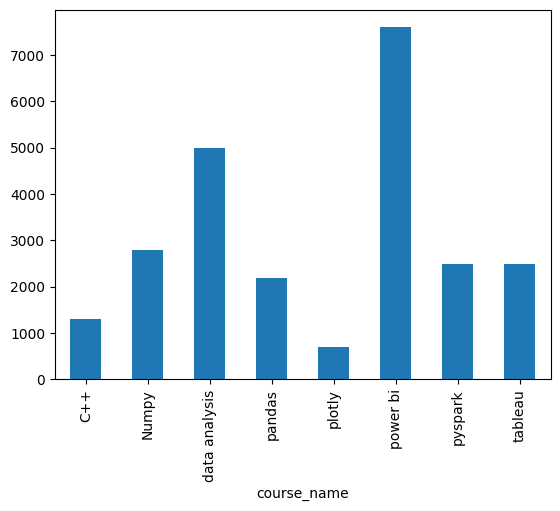

In [ ]:
# 4. Plot bar chart for revenue/course
regs.merge(courses,on='course_id').groupby('course_name')['price'].sum().plot(kind='bar')

In [ ]:
# 5. find students who enrolled in both the months
common_student_id = np.intersect1d(dec['student_id'],nov['student_id'])
common_student_id

array([ 1,  3,  7, 11, 16, 17, 18, 22, 23])

In [ ]:
students[students['student_id'].isin(common_student_id)]

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [ ]:
# 6. find course that got no enrollment
# courses['course_id']
# regs['course_id']
common_id_list = np.setdiff1d(courses['course_id'],regs['course_id'])

courses[courses['course_id'].isin(common_student_id)]

,course_id,course_name,price
0,1,python,2499
2,3,data analysis,4999
6,7,ms sxcel,1599
10,11,Numpy,699


In [ ]:
# 7. find students who did not enroll into any courses
student_id_list = np.setdiff1d(students['student_id'],regs['student_id'])

students[students['student_id'].isin(student_id_list)].shape[0]

(10/28)*100

35.714285714285715

In [ ]:
# 8. Print student name -> partner name for all enrolled students
# self join
students.merge(students,how='inner',left_on='partner',right_on='student_id')[['name_x','name_y']]

,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
...,...,...
56,Ankit,Nitish
57,Ankit,Nitish
58,Ankit,Nitish
59,Ankit,Nitish


In [ ]:
# 9. find top 3 students who did most number enrollments
regs.merge(students,on='student_id').groupby(['student_id','name'])['name'].count().sort_values(ascending=False).head(3)

,,name
student_id,name,
26.0,Nitish,8
23.0,Chhavi Lachman,3
14.0,Pranab Natarajan,2


In [ ]:
# 10. find top 3 students who spent most amount of money on courses
regs.merge(students,on='student_id').merge(courses,on='course_id').groupby(['student_id','name'])['price'].sum().sort_values(ascending=False).head(3)

,,price
student_id,name,
26.0,Nitish,10392
8.0,Radheshyam Dey,4999
23.0,Chhavi Lachman,3297


In [ ]:
# Alternate syntax for merge
# students.merge(regs)
pd.merge(students,regs,how='inner',on='student_id')

,student_id,name,partner,course_id
0,8,Radheshyam Dey,5,3.0
1,13,Munni Varghese,24,11.0
2,14,Pranab Natarajan,22,13.0
3,14,Pranab Natarajan,22,13.0
4,19,Qabeel Raman,12,17.0
5,23,Chhavi Lachman,18,11.0
6,23,Chhavi Lachman,18,6.0
7,23,Chhavi Lachman,18,11.0
8,25,Shashank D’Alia,2,8.0
9,25,Shashank D’Alia,2,13.0


In [ ]:
# IPL Problems

# find top 3 studiums with highest sixes/match ratio
# find orange cap holder of all the seasons

matches

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,632,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN
632,633,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN
633,634,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN
634,635,2016,Delhi,2016-05-27,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,NaN


In [ ]:
delivery

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179073,11415,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,SR Watson,SL Malinga,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN
179074,11415,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,RA Jadeja,SL Malinga,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN
179075,11415,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,RA Jadeja,SL Malinga,0,...,0,0,0,0,1,0,1,SR Watson,run out,KH Pandya
179076,11415,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,RA Jadeja,SL Malinga,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN


In [ ]:
temp_df = delivery.merge(matches,left_on='match_id',right_on='id')

In [ ]:
six_df = temp_df[temp_df['batsman_runs'] == 6]

In [ ]:
# stadium -> sixes

In [ ]:
num_sixes = six_df.groupby('venue')['venue'].count()

In [ ]:
num_matches = matches['venue'].value_counts()

In [ ]:
(num_sixes/num_matches).sort_values(ascending=False).head(10)

,0
venue,
Holkar Cricket Stadium,17.600000
M Chinnaswamy Stadium,13.227273
Sharjah Cricket Stadium,12.666667
Himachal Pradesh Cricket Association Stadium,12.000000
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium,11.727273
Wankhede Stadium,11.526316
De Beers Diamond Oval,11.333333
Maharashtra Cricket Association Stadium,11.266667
JSCA International Stadium Complex,10.857143


In [ ]:
matches

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,632,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN
632,633,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN
633,634,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN
634,635,2016,Delhi,2016-05-27,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,NaN


In [ ]:
temp_df.groupby(['season','batsman'])['batsman_runs'].sum().reset_index().sort_values('batsman_runs',ascending=False).drop_duplicates(subset=['season'],keep='first').sort_values('season')

,season,batsman,batsman_runs
115,2008,SE Marsh,616
229,2009,ML Hayden,572
446,2010,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641


In [ ]:
temp_df.groupby(['season','batsman'])['batsman_runs'].sum().reset_index().sort_values('batsman_runs',ascending=False)

,season,batsman,batsman_runs
1383,2016,V Kohli,973
1278,2016,DA Warner,848
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
852,2013,CH Gayle,720
...,...,...,...
638,2011,VR Aaron,0
1467,2017,MM Patel,0
572,2011,ND Doshi,0
605,2011,S Nadeem,0
